In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import os
import pandas as pd

In [2]:
folders = ['V_1_K_1_allostery','V_10_K_1_allostery','V_1_K_10_allostery','V_10_K_10_allostery']

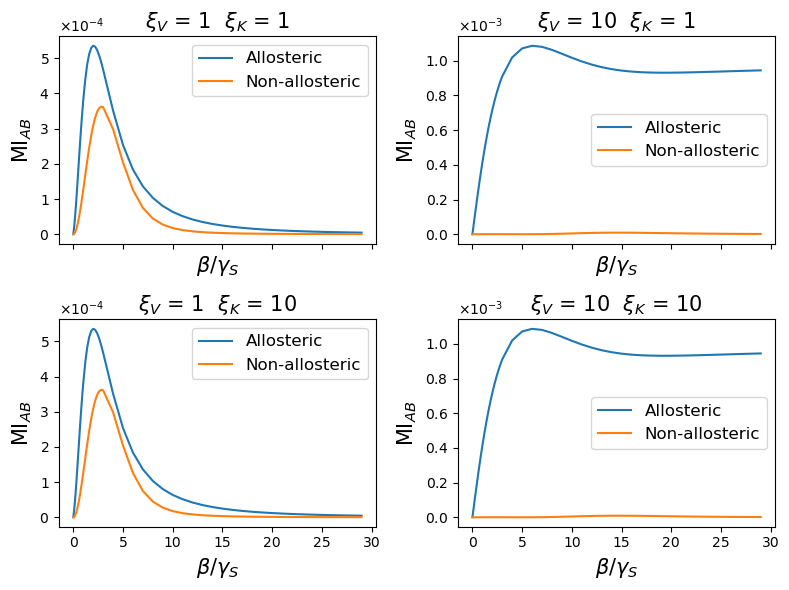

In [ ]:
fig, axs = plt.subplots(2, 2, sharex=True,figsize=(8,6))
for folder,ax in zip(folders,axs.flatten()):
    beta,mi_allo,mi_nonallo = np.loadtxt(folder+'fcases/A_MI.csv').T

    
    ax.plot(beta,mi_allo,label='Allosteric',color='C0')
    ax.plot(beta,mi_nonallo,label='Non-allosteric',color='C1')

    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_position((0, 1.01))  # move exponent above axis
    _,vrate,_,krate,_ = folder.split('_')

    ax.set_xlabel(r'$\beta/\gamma_S$',fontsize=15)
    ax.set_ylabel(r'MI$_{AB}$',fontsize=15)
    ax.set_title(r'$\xi_V$ = {}  $\xi_K$ = {}'.format(vrate,krate),fontsize=15)
    ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('f2',bbox_inches='tight',dpi=600)

In [4]:
folders = ['V_?_K_1_allostery','V_?_K_10_allostery','V_1_K_?_allostery','V_10_K_?_allostery']

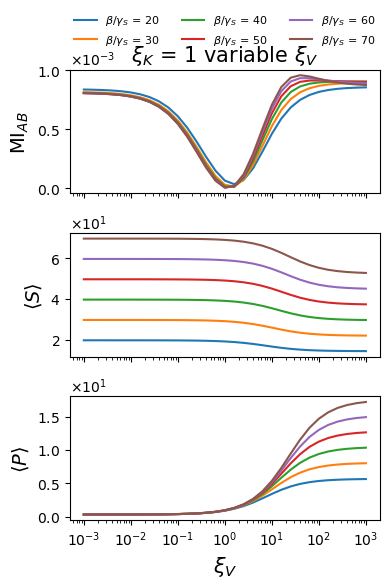

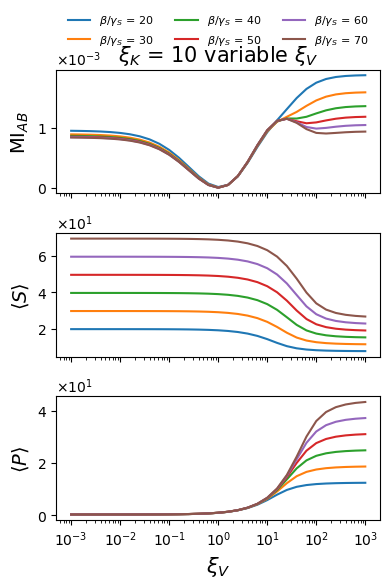

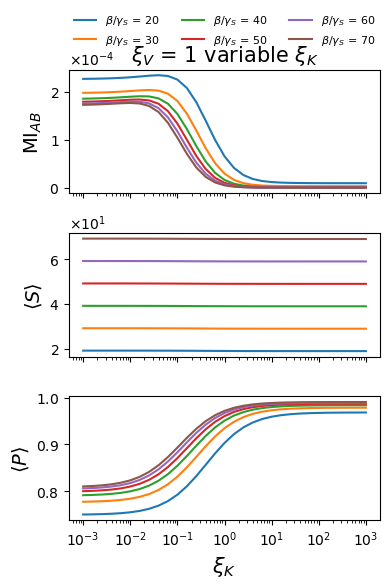

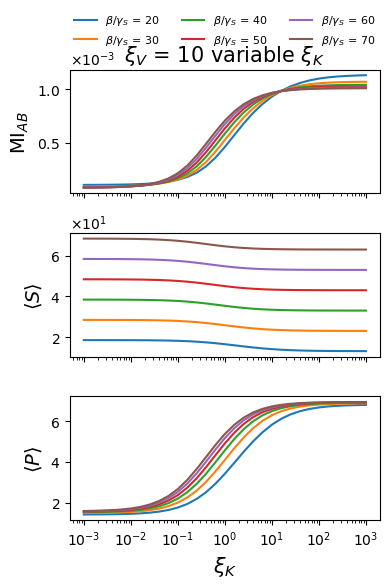

In [ ]:
for folder in folders:
    betas, allos, MI, S, P = np.loadtxt(folder+'fcases/B_report.csv').T

    fig, axs = plt.subplots(3, 1, sharex=True,figsize=(4,6))

    for b in np.unique(betas)[1:-1]:
        axs[0].plot(allos[betas == b], MI[betas == b], label=rf'$\beta/\gamma_S$ = {int(b)}')
        axs[1].plot(allos[betas == b], S[betas == b])
        axs[2].plot(allos[betas == b], P[betas == b])

    # Log scale for last subplot's x-axis
    axs[2].set_xscale('log')
    axs[2].xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'$10^{{{int(np.log10(x))}}}$')
    )

    # Legend outside on top
    axs[0].legend(
        loc='lower center',
        bbox_to_anchor=(0.5, 1.1),
        ncol=3,
        frameon=False,fontsize=8
    )

    # Scientific notation with offset text (outside axis)
    for ax in axs:
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax.yaxis.get_offset_text().set_position((0, 1.01))  # move exponent above axis
 
    _,vrate,_,krate,_ = folder.split('_')

    if vrate == '?':
        axs[-1].set_xlabel(r'$\xi_V$',fontsize=15)
        axs[0].set_title(r'$\xi_K$ = {} variable $\xi_V$'.format(krate),fontsize=15)
    else:
        axs[-1].set_xlabel(r'$\xi_K$',fontsize=15)
        axs[0].set_title(r'$\xi_V$ = {} variable $\xi_K$'.format(vrate),fontsize=15)

    [ax.set_ylabel(g,fontsize=14) for (ax,g) in zip (axs,[r'MI$_{AB}$',
                                            r'$\langle S \rangle$',
                                            r'$\langle P \rangle$',])]

    
    plt.tight_layout()
    #plt.show()
    plt.savefig(folder+'_B_report',bbox_inches='tight',dpi=600)


In [6]:
records = []

files = os.listdir("varallostery")
for file in files:
    try:
        _, vk, beta, shape, times, _ = file.split("_")

        # vk looks like "V=0.1K=10"
        _, xi_v, xi_k = vk.split("=")

        # remove trailing 'K' from xi_v
        xi_v = float(xi_v[:-1])
        xi_k = float(xi_k)
        try:
            times = float(times)
        except:
            times = times

        records.append({
            "xi_v": xi_v,
            "xi_k": xi_k,
            "shape": shape,
            "times": times,
            "beta": beta,
            "file": file
        })
    except ValueError:
        print(f"Skipping file (unexpected format): {file}")

# Convert to DataFrame
df = pd.DataFrame(records)

Skipping file (unexpected format): A_V=1.0_K=10.0_40_varstep_[10. 10.]_report.csv
Skipping file (unexpected format): A_V=1.0_K=20.0_40_triangle_10_report.csv
Skipping file (unexpected format): A_V=0.05_K=1.0_40_varstep_[10. 10.]_report.csv
Skipping file (unexpected format): A_V=10.0_K=20.0_40_varstep_[14.  6.]_report.csv
Skipping file (unexpected format): A_V=0.1_K=1.0_40_varstep_[7. 3.]_report.csv
Skipping file (unexpected format): A_V=10.0_K=0.1_40_varstep_[9. 1.]_report.csv
Skipping file (unexpected format): A_V=0.1_K=1.0_40_triangle_10_report.csv
Skipping file (unexpected format): A_V=1.0_K=10.0_40_varstep_[14.  6.]_report.csv
Skipping file (unexpected format): A_V=10.0_K=0.05_40_varstep_[14.  6.]_report.csv
Skipping file (unexpected format): A_V=10.0_K=0.05_40_varstep_[18.  2.]_report.csv
Skipping file (unexpected format): A_V=1.0_K=0.05_40_varstep_[5. 5.]_report.csv
Skipping file (unexpected format): A_V=0.1_K=1.0_40_varstep_[14.  6.]_report.csv
Skipping file (unexpected format):

In [7]:
def make_plot(df, title,tmax =-1):

    fig, axs = plt.subplots(4, 1, sharex=True,figsize=(4,8))
    for i, row in df.iterrows():
        file = row['file']
        xi_v = row['xi_v']
        xi_k = row['xi_k']
        #times = row['times']
        
        t,betas,S,P,MI = np.loadtxt('varallostery/'+file).T
        if tmax > 0:
            t,betas,S,P,MI = t[t<=tmax],betas[t<=tmax],S[t<=tmax],P[t<=tmax],MI[t<=tmax] 

        axs[0].plot(t, betas, linewidth = 5, color='k')
        if np.all(df['xi_k'] == xi_k):
            axs[0].set_title(r'$\xi_K$ = {} variable $\xi_V$'.format(xi_k),fontsize=15)
            axs[1].plot(t, MI, label=rf'$\xi_V$ = {xi_v:.2f}')
        elif np.all(df['xi_v'] == xi_v):
            axs[0].set_title(r'$\xi_V$ = {} variable $\xi_K$'.format(xi_v),fontsize=15)
            axs[1].plot(t, MI, label=rf'$\xi_K$ = {xi_k:.2f}')
        axs[2].plot(t,S)
        axs[3].plot(t,P)

    axs[-1].set_xlim(t[0],t[-1])

    [ax.set_ylabel(g,fontsize=14) for (ax,g) in zip (axs,[r'$\beta/\gamma_S$',
                                                        r'MI$_{AB}$',
                                                        r'$\langle S \rangle$',r'$\langle P \rangle$',])]

    for ax in axs[1:]:
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax.yaxis.get_offset_text().set_position((0, 1.01))  # move exponent above axis

        ymin, ymax = ax.get_ylim()
        m = max(abs(ymin), abs(ymax))
        n = int(np.floor(np.log10(m)))

        if n>0:
            base = 3 * (10 ** n)      # 0, 3, 6 ... × 10^n
            ax.yaxis.set_major_locator(ticker.MultipleLocator(base=base))
            ax.set_ylim(0,np.ceil(m/10)*10)
    #axs[0].set_title(r'$\xi_k$ = 10 variable $\xi_V$',fontsize=15)
    axs[-1].set_xlabel(r'time',fontsize=15)
    fig.legend(
        loc='lower center',
        bbox_to_anchor=(0.5, .9),
        ncol=3,
        frameon=False,fontsize=8
    )
    fig.savefig('varallostery_'+title+'.png',bbox_inches='tight',dpi=600)

In [8]:
tri_k1 =  (df[(df["shape"] == "triangle") & (df["xi_k"] == 1)]).sort_values(by='xi_v')
tri_k10 = (df[(df["shape"] == "triangle") & (df["xi_k"] == 10)]).sort_values(by='xi_v')
tri_v1 =  (df[(df["shape"] == "triangle") & (df["xi_v"] == 1)]).sort_values(by='xi_k')
tri_v10 = (df[(df["shape"] == "triangle") & (df["xi_v"] == 10)]).sort_values(by='xi_k')

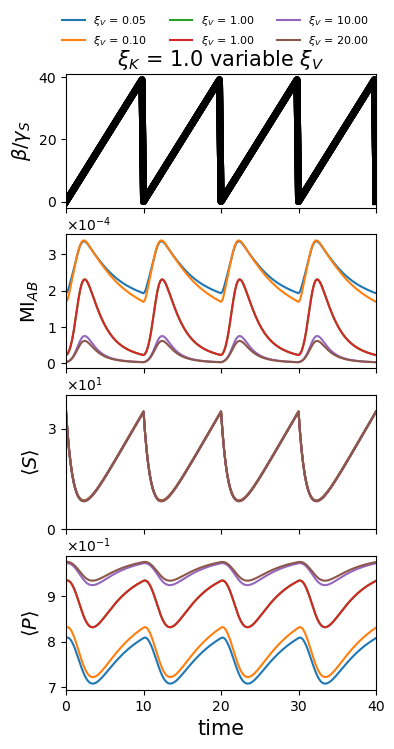

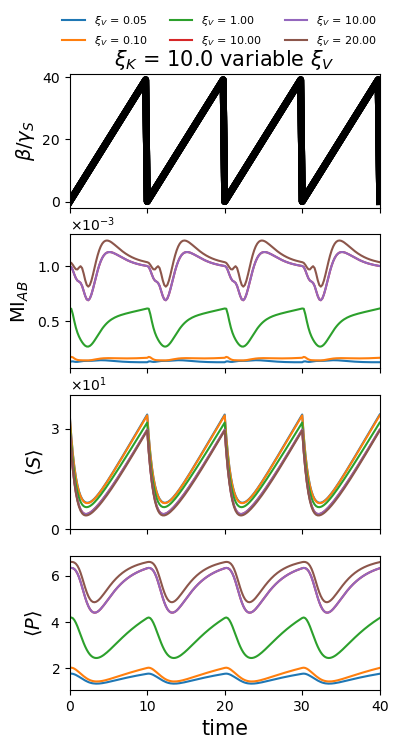

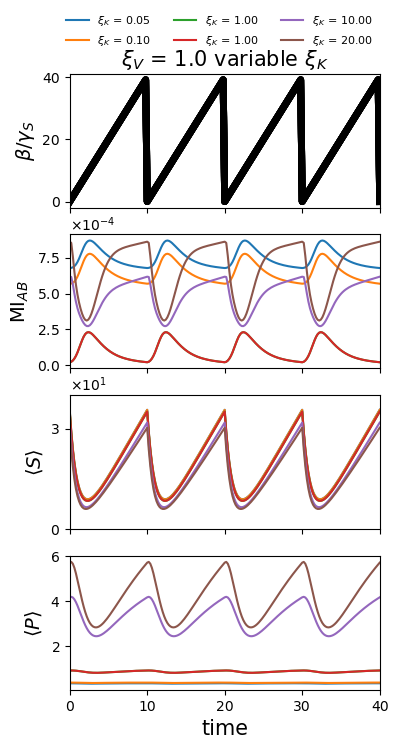

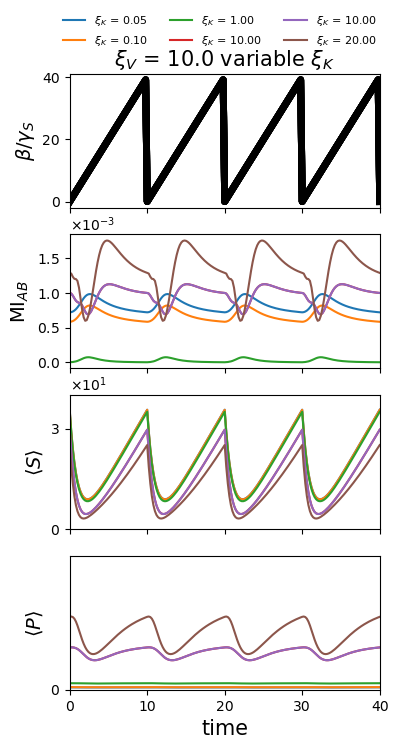

In [9]:
make_plot(tri_k1, 'triangle_k=1_report',tmax=40)
make_plot(tri_k10,'triangle_k=10_report',tmax=40)
make_plot(tri_v1, 'triangle_v=1_report_v',tmax=40)
make_plot(tri_v10,'triangle_v=10_report_v',tmax=40)


In [10]:
step_k1 =  df[(df['shape'] == 'varstep') & (df['times'] == '[14.  6.]') & (df['xi_k'] == 1) ].sort_values(by='xi_v')
step_k10 = df[(df['shape'] == 'varstep') & (df['times'] == '[14.  6.]') & (df['xi_k'] == 10)].sort_values(by='xi_v')
step_v1 =  df[(df['shape'] == 'varstep') & (df['times'] == '[14.  6.]') & (df['xi_v'] == 1) ].sort_values(by='xi_k')
step_v10 = df[(df['shape'] == 'varstep') & (df['times'] == '[14.  6.]') & (df['xi_v'] == 10)].sort_values(by='xi_k')

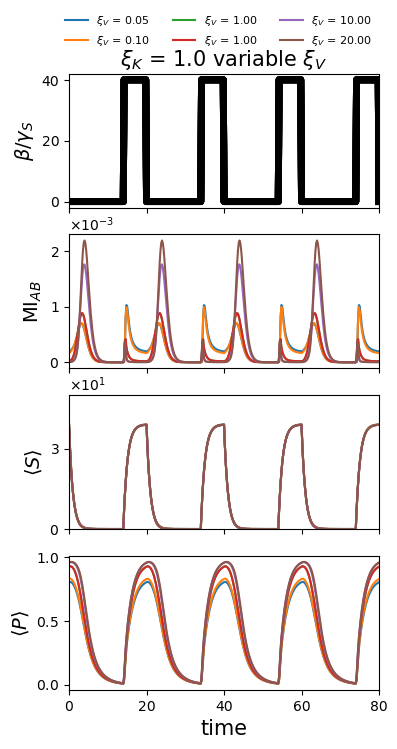

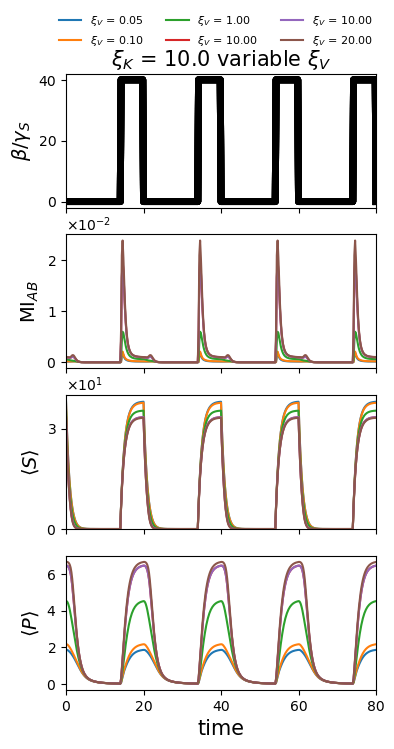

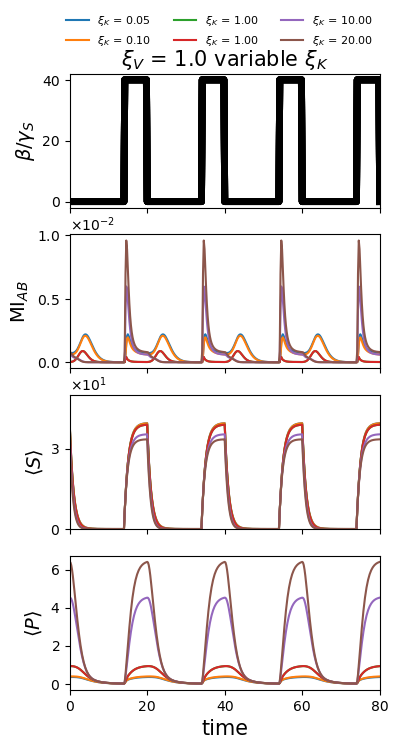

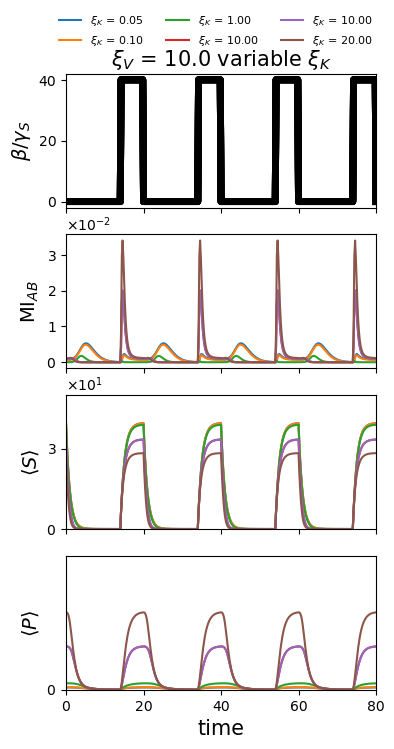

In [11]:
make_plot(step_k1, 'step_k=1_report_14_6')
make_plot(step_k10,'step_k=10_report_14_6')
make_plot(step_v1, 'step_v=1_report_14_6')
make_plot(step_v10,'step_v=10_report_14_6')

In [23]:
step_k1 =  df[(df['shape'] == 'varstep') & (df['times'] == '[10. 10.]') & (df['xi_k'] == 1) ].sort_values(by='xi_v')
step_k10 = df[(df['shape'] == 'varstep') & (df['times'] == '[10. 10.]') & (df['xi_k'] == 10)].sort_values(by='xi_v')
step_v1 =  df[(df['shape'] == 'varstep') & (df['times'] == '[10. 10.]') & (df['xi_v'] == 1) ].sort_values(by='xi_k')
step_v10 = df[(df['shape'] == 'varstep') & (df['times'] == '[10. 10.]') & (df['xi_v'] == 10)].sort_values(by='xi_k')

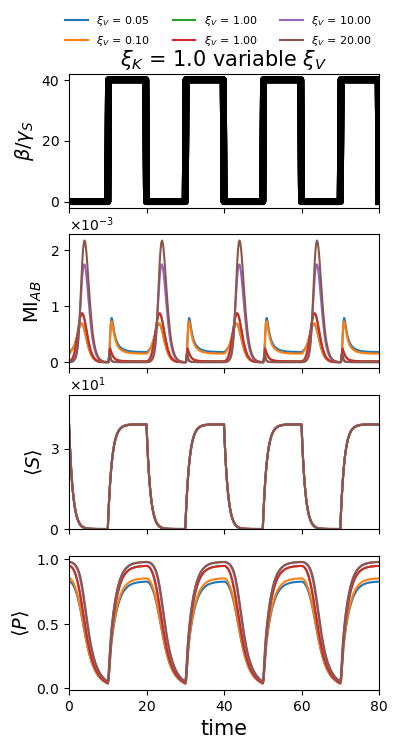

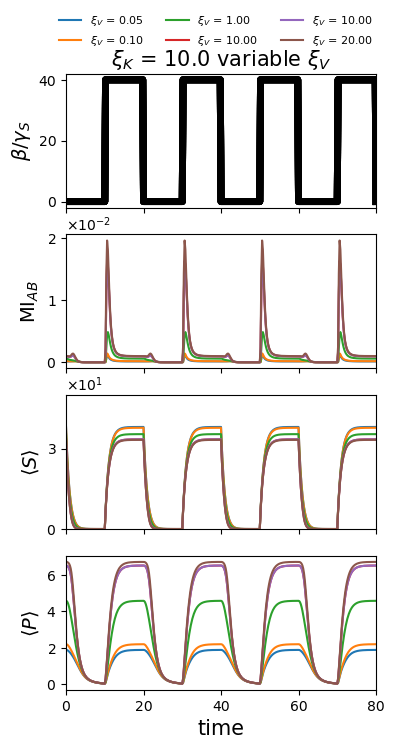

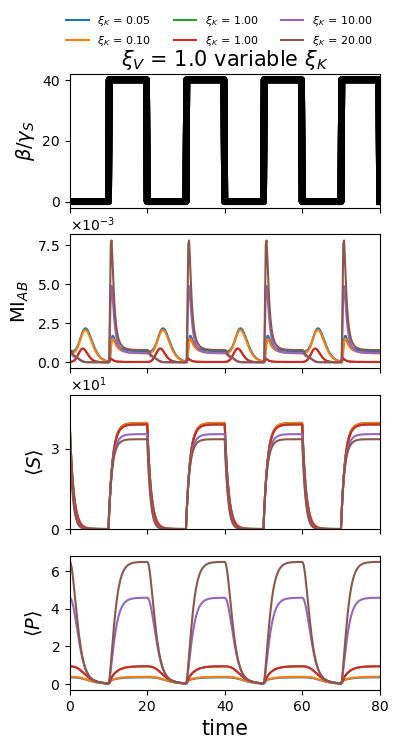

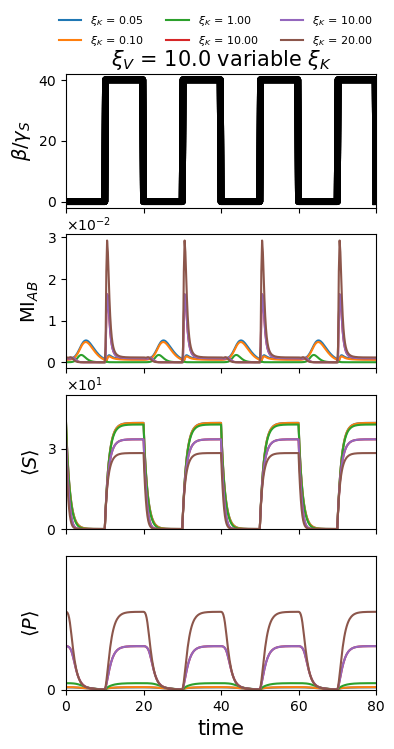

In [24]:
make_plot(step_k1, 'step_k=1_report_10_10')
make_plot(step_k10,'step_k=10_report_10_10')
make_plot(step_v1, 'step_v=1_report_10_10')
make_plot(step_v10,'step_v=10_report_10_10')